In [2]:
import glob
import os
import io
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import polars.selectors as cs
import sklearn.metrics as metrics
import scipy.stats as st

from hta.trace_analysis import TraceAnalysis
from plot_utils import plot_xy, plot_bar

In [3]:
v100_power_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
    .with_columns(
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
    .rename({"power_w": "v100_measured_power_W", "time_us": "v100_measured_total_time_us"})
)

In [4]:
a30_power_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/A30/*/power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/A30/(.*)/power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("cpu_ts").max() - pl.col("cpu_ts").min()
        ) * 1e6,
        time_us = (pl.col("cpu_ts").max() - pl.col("cpu_ts").min()) / 10000 / 1000
    )
    .rename({"power_w": "a30_measured_power_W", "time_us": "a30_measured_total_time_us"})
)

In [5]:
results = []

for trace_dir in glob.glob("/proj/threadtune-PG0/amir/kineto_traces/*"):
    benchmark_name = os.path.basename(trace_dir)
    json_path = os.path.join(trace_dir, "device.0.json")

    kineto_df = (
        pl.read_json(json_path)
        .select(pl.col("traceEvents").explode().struct.unnest())
    )

    total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
    total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

    if total_trace_dur is None: total_trace_dur = 0
    if total_kernel_dur is None: total_kernel_dur = 0
    
    idle_time_us = total_trace_dur - total_kernel_dur
   
    results.append({
        "benchmark": benchmark_name,
        "v100_measured_idle_time_us": idle_time_us
    })

v100_idle_df = pl.DataFrame(results)

In [6]:
results = []

for trace_dir in glob.glob("/proj/threadtune-PG0/amir/A30/*"):
    benchmark_name = os.path.basename(trace_dir)
    json_path = os.path.join(trace_dir, "device.0.json")

    kineto_df = (
        pl.read_json(json_path)
        .select(pl.col("traceEvents").explode().struct.unnest())
    )

    total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
    total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

    if total_trace_dur is None: total_trace_dur = 0
    if total_kernel_dur is None: total_kernel_dur = 0
    
    idle_time_us = total_trace_dur - total_kernel_dur
   
    results.append({
        "benchmark": benchmark_name,
        "a30_measured_idle_time_us": idle_time_us
    })

a30_idle_df = pl.DataFrame(results)

In [7]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/kineto_traces/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    sym = analyzer.t.symbol_table.get_sym_table()
    
    dfs.append(pl.concat([
        pl.from_pandas(analyzer.t.get_trace(r)[analyzer.t.get_trace(r)["stream"] != -1][["name", "dur"]])
        for r in analyzer.t.traces
    ]).join(
        pl.from_dict({"name": list(range(len(sym))), "s_name": sym}), on="name"
    ).filter(
        ~pl.col("s_name").str.starts_with("nccl") & 
        ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
    ).select(
        pl.lit(d.name).alias("benchmark"),
        pl.col("dur").sum().alias("v100_measured_kernel_time_sum_us")
    ))

v100_time_df = pl.concat(dfs)

Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.21 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=json in 0.44 seconds; current PID:35209
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.50 seconds; current PID:35209
leaving parse_multiple_ranks duration=0.51 seconds
leaving parse_traces duration=0.51 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.15 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-

In [8]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/A30/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    sym = analyzer.t.symbol_table.get_sym_table()
    
    dfs.append(pl.concat([
        pl.from_pandas(analyzer.t.get_trace(r)[analyzer.t.get_trace(r)["stream"] != -1][["name", "dur"]])
        for r in analyzer.t.traces
    ]).join(
        pl.from_dict({"name": list(range(len(sym))), "s_name": sym}), on="name"
    ).filter(
        ~pl.col("s_name").str.starts_with("nccl") & 
        ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
    ).select(
        pl.lit(d.name).alias("benchmark"),
        pl.col("dur").sum().alias("a30_measured_kernel_time_sum_us")
    ))

a30_time_df = pl.concat(dfs)

Parsed /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json time = 0.03 seconds 


Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json backend=json in 0.12 seconds; current PID:35209
Overall parsing of /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json in 0.15 seconds; current PID:35209
leaving parse_multiple_ranks duration=0.15 seconds
leaving parse_traces duration=0.15 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/A30/gemma-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/A30/gemma-inference/device.0.json backend=json in 0.09 seconds; current PID:35209
Overall parsing of /proj/threadtune-PG0/amir/A30/ge

In [60]:
final_df = (
    v100_power_df
    .join(v100_idle_df, on="benchmark")
    .join(v100_time_df, on="benchmark")
    .join(a30_power_df, on="benchmark")
    .join(a30_idle_df, on="benchmark")
    .join(a30_time_df, on="benchmark")
)
final_df.select("v100_measured_total_time_us").describe()

statistic,v100_measured_total_time_us
str,f64
"""count""",11.0
"""null_count""",0.0
"""mean""",34578.480803
"""std""",15009.064205
"""min""",10755.061665
"""25%""",22697.103064
"""50%""",41119.958221
"""75%""",45746.64186
"""max""",53658.204805


Text(0, 0.5, 'Idle Percentage (%)')

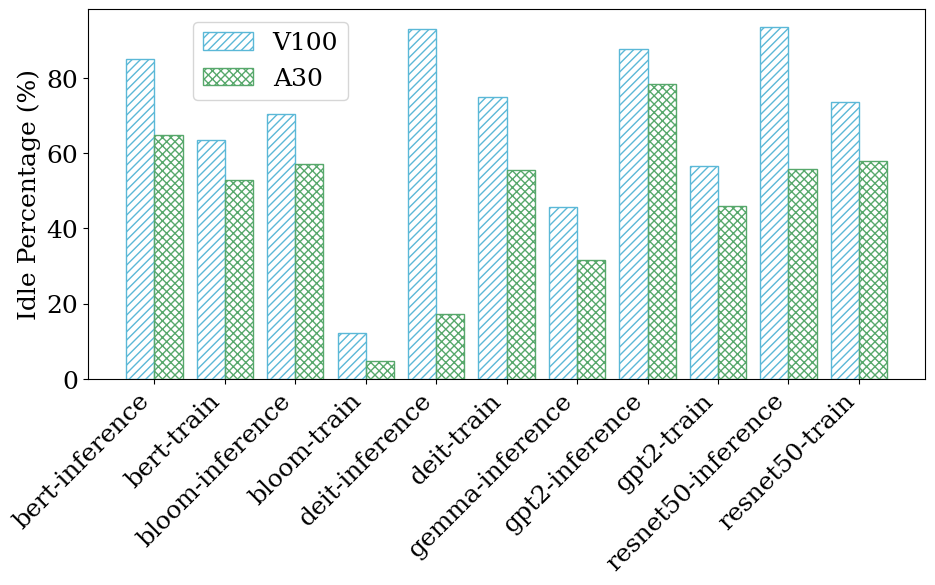

In [45]:
v100_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("V100").alias("device"),
    ((pl.col("v100_measured_total_time_us") - pl.col("v100_measured_kernel_time_sum_us"))/1000).alias("modeled_idle_ms"),
    pl.col("v100_measured_idle_time_us").alias("measured_idle_us"),
    ((pl.col("v100_measured_total_time_us") - pl.col("v100_measured_kernel_time_sum_us"))  * 100 / pl.col("v100_measured_total_time_us")).alias("modeled_idle_pct")
).sort(by="benchmark")

a30_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("A30").alias("device"),
    ((pl.col("a30_measured_total_time_us") - pl.col("a30_measured_kernel_time_sum_us"))/1000).alias("modeled_idle_ms"),
    pl.col("a30_measured_idle_time_us").alias("measured_idle_us"),
    ((pl.col("a30_measured_total_time_us") - pl.col("a30_measured_kernel_time_sum_us")) * 100 / pl.col("a30_measured_total_time_us")).alias("modeled_idle_pct")
).sort(by="benchmark")

plot_df = pl.concat([v100_data, a30_data]).sort(by="benchmark")

ax = plot_bar(
    plot_df, 
    x="benchmark", 
    y="modeled_idle_pct", 
    hue="device", 
    # ylabel="modeled_idle_ms", 
    ndigits=1
)
ax.legend(loc='upper left', bbox_to_anchor=(0.11, 1.0))

ax.set_ylabel("Idle Percentage (%)")

/tmp/ipykernel_35209/4258215874.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Leave space on top for legend


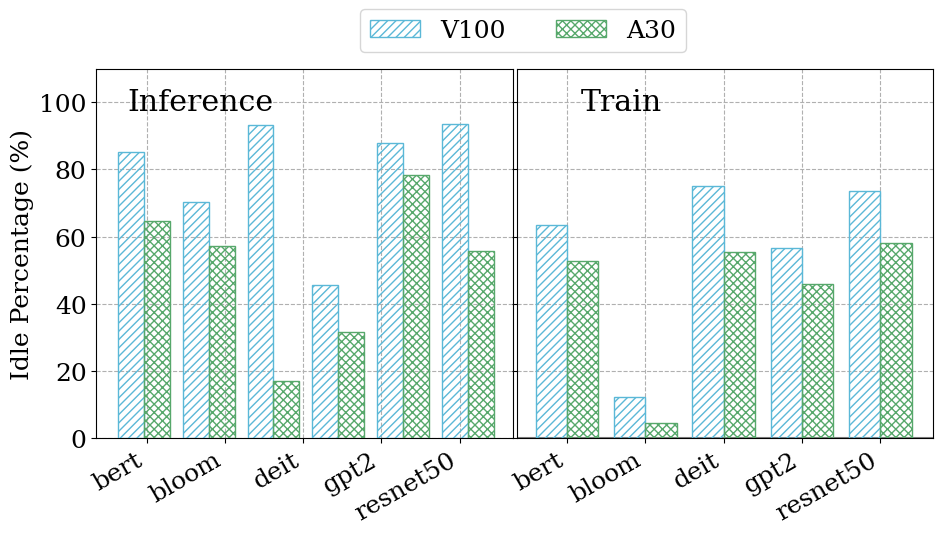

In [58]:
import matplotlib.pyplot as plt
from matplotlib.figure import figaspect

plot_df = plot_df.with_columns(
        pl.col("benchmark").str.split("-").list.first().alias("model"),
        pl.col("benchmark").str.split("-").list.last().alias("phase")
    )

w, h = figaspect(0.4/0.9)
# Create subplots
fig, axs = plt.subplots(
    1, 2, 
    figsize=(w, h), 
    # gridspec_kw={'width_ratios': [4.5, 3.5]},
    gridspec_kw={'wspace': 0.01, 'hspace': 0.05},
    sharex=True,
    sharey=True,
)

# Plot data on both axes
plot_bar(
    plot_df.filter(
        pl.col("phase") == "inference"
    ), 
    x="model", 
    y="modeled_idle_pct", 
    hue="device", 
    # ylabel="modeled_idle_ms", 
    ax=axs[0],
    ndigits=1,
    w=w*0.5
)
axs[0].set_title("Inference", x=0.25,  y=1.0, pad=-30)
axs[0].get_legend().remove()

plot_bar(
    plot_df.filter(
        ~(pl.col("phase") == "inference")
    ), 
    x="model", 
    y="modeled_idle_pct", 
    hue="device", 
    # ylabel="modeled_idle_ms", 
    ax=axs[1],
    ndigits=1,
    w=w*0.5
)
axs[1].set_title("Train", x=0.25,  y=1.0, pad=-30)
axs[1].get_legend().remove()

# Create a shared legend
# axes[0][0].legend(ncol=3, prop={'size': 18}, loc=9)
handles, labels = axs[0].get_legend_handles_labels()

# Set a single shared legend for the whole figure
fig.legend(
    handles=handles,
    labels=labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.52, 1.03)
)

for i, ax in enumerate(axs.flat):
    ax.tick_params(axis='x', labelrotation=30)  # Set x-tick label font size
    ax.grid(linestyle='--',zorder=0)

axs[0].set_ylabel("Idle Percentage (%)")

plt.ylim(ymin=0, ymax=110)
plt.axhline(0, color='gray')
plt.tight_layout()  # Leave space on top for legend
plt.savefig(f"Figure_5.pdf",bbox_inches='tight',pad_inches=0.1)

In [50]:
plot_df

benchmark,device,modeled_idle_ms,measured_idle_us,modeled_idle_pct,model,phase
str,str,f64,f64,f64,str,str
"""bert-inference""","""V100""",9.154062,312991.064,85.113986,"""bert""","""inference"""
"""bert-inference""","""A30""",3.966899,277934.729,64.777339,"""bert""","""inference"""
"""bert-train""","""V100""",34.061205,631781.294,63.478092,"""bert""","""train"""
"""bert-train""","""A30""",26.444646,472348.223,52.813614,"""bert""","""train"""
"""bloom-inference""","""V100""",10.716402,553572.69,70.398889,"""bloom""","""inference"""
…,…,…,…,…,…,…
"""gpt2-train""","""A30""",23.350971,436709.734,45.970125,"""gpt2""","""train"""
"""resnet50-inference""","""V100""",38.464958,380508.952,93.543281,"""resnet50""","""inference"""
"""resnet50-inference""","""A30""",2.675204,261404.998,55.754278,"""resnet50""","""inference"""
